# ACTIVIDAD : Redes Convolucionales

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar imágenes de personajes los Simpsons.

<center><img src="https://i.imgur.com/i8zIGqX.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en imágenes de personajes de la serie extraídas directamente de capítulos de la serie. Este dataset ha sido recopilado por [Alexandre Attia](http://www.alexattia.fr/)
Partiendo de los 18 personajes etiquetados, éstos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros personajes en pantalla (si bien el personaje a clasificar siempre aparece en la posición predominante).

El dataset de training puede ser descargado desde aquí:

[Training data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60) (~500MB)

Por otro lado, el dataset de test puede ser descargado de aquí:

[Test data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219341&authkey=ANnjK3Uq1FhuAe8) (~10MB)

Antes de empezar la práctica, se recomienda descargar las imágenes y echarlas un vistazo.


## Carga de librerías y comprobación de GPU

In [1]:
import os
import math
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision import datasets, models
import kagglehub

c:\Users\Delante\Desktop\DatosNoEstructutads\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 5070
VRAM: 12.8 GB


## Carga de datos

Nos descargamos la carpeta de la web de Kaggle:
https://www.kaggle.com/datasets/alexattia/the-simpsons-characters-dataset?resource=download&select=simpsons_dataset

In [3]:
# Descargar dataset
path = kagglehub.dataset_download("alexattia/the-simpsons-characters-dataset")
print("Descargado en:", path)

# Definir rutas
source_path = os.path.join(path, "simpsons_dataset")
target_path = "./simpsons_dataset"

# Si ya existe, eliminar y copiar de nuevo
if os.path.exists(target_path):
    shutil.rmtree(target_path)
    print(f"Carpeta existente eliminada: {target_path}")

shutil.copytree(source_path, target_path)
print(f"Dataset copiado a: {target_path}")

Descargado en: C:\Users\Delante\.cache\kagglehub\datasets\alexattia\the-simpsons-characters-dataset\versions\4
Carpeta existente eliminada: ./simpsons_dataset
Dataset copiado a: ./simpsons_dataset


In [4]:
# Contamos el número de repeticiones de cada personaje
dataset_dir = target_path
conteo_imagenes = {}

for cls in sorted(os.listdir(dataset_dir)):
    cls_path = os.path.join(dataset_dir, cls)
    if os.path.isdir(cls_path):
        imagenes = [f for f in os.listdir(cls_path) if f.endswith('.jpg')]
        conteo_imagenes[cls] = len(imagenes)

# Mostrar resultados ordenados
for cls, count in sorted(conteo_imagenes.items(), key=lambda x: x[1]):
    print(f"{cls:30s} -> {count} imágenes")

simpsons_dataset               -> 0 imágenes
lionel_hutz                    -> 3 imágenes
disco_stu                      -> 8 imágenes
troy_mcclure                   -> 8 imágenes
miss_hoover                    -> 17 imágenes
fat_tony                       -> 27 imágenes
gil                            -> 27 imágenes
otto_mann                      -> 32 imágenes
sideshow_mel                   -> 40 imágenes
agnes_skinner                  -> 42 imágenes
rainier_wolfcastle             -> 45 imágenes
cletus_spuckler                -> 47 imágenes
snake_jailbird                 -> 55 imágenes
professor_john_frink           -> 65 imágenes
martin_prince                  -> 71 imágenes
patty_bouvier                  -> 72 imágenes
ralph_wiggum                   -> 89 imágenes
carl_carlson                   -> 98 imágenes
selma_bouvier                  -> 103 imágenes
barney_gumble                  -> 106 imágenes
groundskeeper_willie           -> 121 imágenes
maggie_simpson                 -> 1

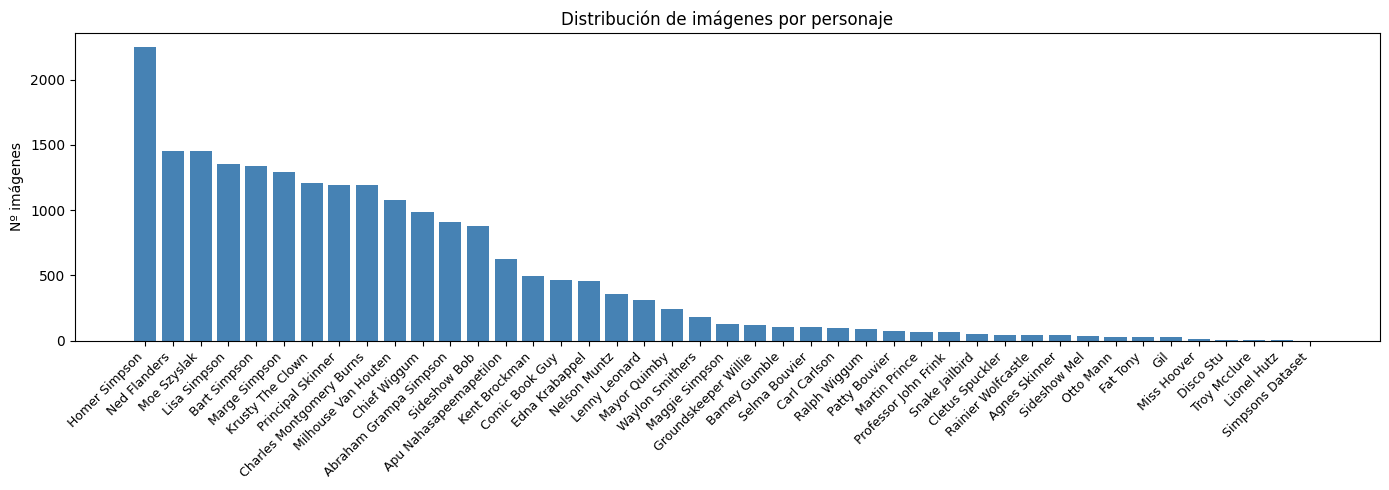

Total imágenes: 20933
Dataset desbalanceado → se usará WeightedRandomSampler en entrenamiento


In [5]:
# Visualización de la distribución de clases
sorted_classes = sorted(conteo_imagenes.items(), key=lambda x: x[1], reverse=True)
nombres = [c[0].replace('_', ' ').title() for c in sorted_classes]
counts  = [c[1] for c in sorted_classes]

plt.figure(figsize=(14, 5))
plt.bar(nombres, counts, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Nº imágenes')
plt.title('Distribución de imágenes por personaje')
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150)
plt.show()

print(f"Total imágenes: {sum(counts)}")
print(f"Dataset desbalanceado → se usará WeightedRandomSampler en entrenamiento")


Como Lionel solo tiene tres imágenes, lo quitamos del entrenamiento

In [6]:
# Eliminar clase con muy pocas imágenes
if os.path.exists("./simpsons_dataset/lionel_hutz"):
    shutil.rmtree("./simpsons_dataset/lionel_hutz")
    print("Eliminada clase 'lionel_hutz' (solo 3 imágenes)")

Eliminada clase 'lionel_hutz' (solo 3 imágenes)


## División de conjunto de datos

Ahora generaremos diferentes carpetas separando los datos de train, test y validación

In [7]:
# Definimos los paths
ORIGINAL_DATASET_DIR = './simpsons_dataset'
BASE_OUTPUT_DIR = './simpsons_split_dataset'

# Porcentajes; he optado por generar sets de train, test y validación.
# Pero podéis variar los porcentajes
train_pct = 0.7
val_pct = 0.15
test_pct = 0.15

# Crear estructura de carpetas eliminando clases vacías
splits = ['train', 'val', 'test']
CLASES_EXCLUIDAS = {'simpsons_dataset', 'lionel_hutz'}

classes = os.listdir(ORIGINAL_DATASET_DIR)
classes = [
    cls for cls in classes
    if os.path.isdir(os.path.join(ORIGINAL_DATASET_DIR, cls))
    and cls not in CLASES_EXCLUIDAS
]

print(f"{len(classes)} clases encontradas")

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(BASE_OUTPUT_DIR, split, cls), exist_ok=True)

# Dividir y copiar imágenes
for cls in classes:
    cls_path = os.path.join(ORIGINAL_DATASET_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith('.jpg')]
    random.shuffle(images)

    # Asignación predeterminada
    train, val, test = [], [], []

    if len(images) >= 3:
        train, temp = train_test_split(images, train_size=train_pct, random_state=42)
        val, test = train_test_split(temp, test_size=test_pct / (test_pct + val_pct), random_state=42)
    else:
        # Si hay muy pocas imágenes, lo mandamos todo al entrenamiento
        train = images
        print(f"[Aviso] Clase '{cls}' tiene muy pocas imágenes ({len(images)}). Se asignan todas a entrenamiento.")

    for img_list, split in zip([train, val, test], ['train', 'val', 'test']):
        for img in img_list:
            src = os.path.join(cls_path, img)
            dst = os.path.join(BASE_OUTPUT_DIR, split, cls, img)
            shutil.copyfile(src, dst)
            
NUM_CLASES = len(classes)
print(f"Número de clases: {NUM_CLASES}")


41 clases encontradas
Número de clases: 41


In [8]:
## Crear diccionario de mapeo automáticamente
MAP_CHARACTERS = {i: cls for i, cls in enumerate(sorted(classes))}
MAP_CHARACTERS

{0: 'abraham_grampa_simpson',
 1: 'agnes_skinner',
 2: 'apu_nahasapeemapetilon',
 3: 'barney_gumble',
 4: 'bart_simpson',
 5: 'carl_carlson',
 6: 'charles_montgomery_burns',
 7: 'chief_wiggum',
 8: 'cletus_spuckler',
 9: 'comic_book_guy',
 10: 'disco_stu',
 11: 'edna_krabappel',
 12: 'fat_tony',
 13: 'gil',
 14: 'groundskeeper_willie',
 15: 'homer_simpson',
 16: 'kent_brockman',
 17: 'krusty_the_clown',
 18: 'lenny_leonard',
 19: 'lisa_simpson',
 20: 'maggie_simpson',
 21: 'marge_simpson',
 22: 'martin_prince',
 23: 'mayor_quimby',
 24: 'milhouse_van_houten',
 25: 'miss_hoover',
 26: 'moe_szyslak',
 27: 'ned_flanders',
 28: 'nelson_muntz',
 29: 'otto_mann',
 30: 'patty_bouvier',
 31: 'principal_skinner',
 32: 'professor_john_frink',
 33: 'rainier_wolfcastle',
 34: 'ralph_wiggum',
 35: 'selma_bouvier',
 36: 'sideshow_bob',
 37: 'sideshow_mel',
 38: 'snake_jailbird',
 39: 'troy_mcclure',
 40: 'waylon_smithers'}

## Ejercicio

Utilizando Convolutional Neural Networks, entrenar al menos dos clasificadores que sean capaz de reconocer personajes en imágenes de los Simpsons con una accuracy en el dataset de test de, al menos, **90%**. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos, pero cuánta más información podáis aportar mejor a la hora de desarrollar vuestro modelo):

*   Análisis de los datos a utilizar. ¿Qué distribución siguen? ¿Están las clases balanceadas?
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes o qué personajes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected (sin convolución) para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.


Notas:
* Los datos están en una única carpeta, por lo que tendrás que hacer el split entre train y test
* Recuerda partir los datos en training/validation para tener una buena estimación de los valores que nuestro modelo tendrá en los datos de test, así como comprobar que no estamos cayendo en overfitting. Una posible partición puede ser 80 / 20.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo de al menos los dos mejores modelos obtenidos y la evaluación de los datos de test con estos modelos**.
* Las imágenes **no están normalizadas**. Hay que normalizarlas como hemos hecho en trabajos anteriores.
* El test set del problema tiene imágenes un poco más sencillas de identificar, por lo que es posible encontrarse con métricas en el test set bastante mejores que en el training set.

## Preprocesado de datos

In [9]:
IMG_SIZE   = 224 # Tamaño de redimensionamiento
BATCH_SIZE = 32 # Tamaño de grupos para procesamiento 

# Normalización de ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transformacion datos entrenamiento (Se aplica Data Augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Al conjunto de val y test solo se normaliza y redimensiona. No se aplica Data Augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Carga de los datos
train_dataset = datasets.ImageFolder('./simpsons_split_dataset/train', transform=train_transform)
val_dataset   = datasets.ImageFolder('./simpsons_split_dataset/val',   transform=val_test_transform)
test_dataset  = datasets.ImageFolder('./simpsons_split_dataset/test',  transform=val_test_transform)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 20924 | Val: 14214 | Test: 14282


Como el dataset está desbalanceado, usamos WeightedRandomSampler, sin esto la red aprendería a predecir siempre a Homer. El sampler asigna a cada imagen un peso inverso al tamaño de su clase: las clases pequeñas se muestrean más frecuentemente para compensar.

In [10]:
# WeightedRandomSampler para clases desbalanceadas
class_counts   = Counter(train_dataset.targets) # Contamos el número de imágenes de cada clase
sample_weights = [1.0 / class_counts[t] for t in train_dataset.targets] # Asigna a cada imagen un peso inverso al tamaño de su clase.
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True) # Usa esos pesos para decidir qué imágenes meter en cada batch. 

# Usamos el sampler sobre los datos de train
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,   num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,     num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,     num_workers=4, pin_memory=True)

# Creamos diccionario
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
class_names  = [idx_to_class[i] for i in range(NUM_CLASES)]
print("DataLoaders listos.")

DataLoaders listos.


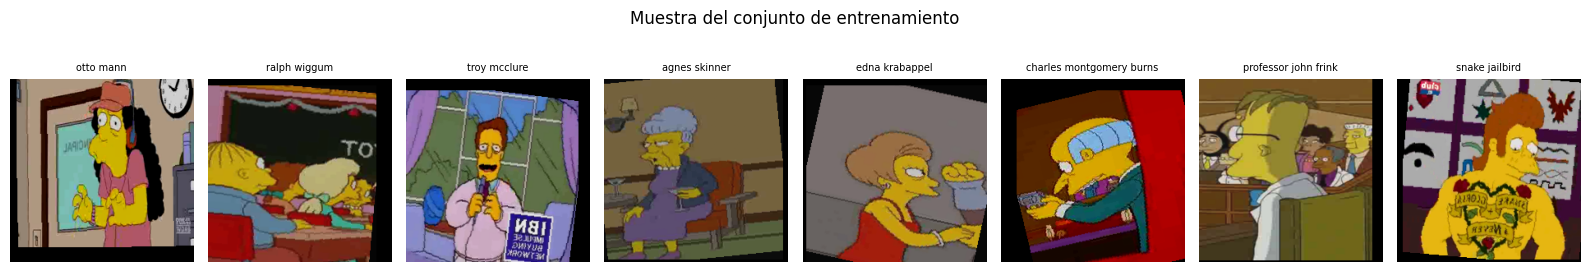

In [11]:
# Visualizamos muestra del dataset
def imshow_batch(loader, n=8):
    imgs, labels = next(iter(loader))
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    imgs = (imgs[:n] * std + mean).clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(16, 3))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i].permute(1,2,0).numpy())
        ax.set_title(idx_to_class[labels[i].item()].replace('_',' '), fontsize=7)
        ax.axis('off')
    plt.suptitle('Muestra del conjunto de entrenamiento')
    plt.tight_layout()
    plt.savefig('muestra_train.png', dpi=150)
    plt.show()

imshow_batch(train_loader)

## Funciones de Entrenamiento y Evaluación de los modelos

In [12]:
# Función de entrenamiento por epoch
def train_one_epoch(model, loader, optimizer, criterion, device):
  model.train()
  running_loss, correct, total = 0.0, 0, 0 # Inicializamos contadores
    
  # Iteramos por todos los batches del DataLoader
  for imgs, labels in loader:
    imgs, labels = imgs.to(device), labels.to(device) # Hacemos el cálculo en GPU
    optimizer.zero_grad() # Limpiamos los gradientes del paso anterior
    outputs = model(imgs) # Forward propagation
    loss = criterion(outputs, labels) # Calculamos la pérdida
    loss.backward() # Back propagation
    optimizer.step() # Actualizamos pesos
    running_loss += loss.item() * imgs.size(0)
    _, preds = outputs.max(1)
    correct += preds.eq(labels).sum().item()
    total += imgs.size(0)
  return running_loss / total, correct / total

# Función de evaluación de modelo sobre val o test
def evaluate(model, loader, criterion, device):
  model.eval()
  running_loss, correct, total = 0.0, 0, 0 # Inicializamos contadores
  
  with torch.no_grad(): # Desasctivamos el cálculo del gradiente
    for imgs, labels in loader: # Iteramos sobre los batches del DataLoader
      imgs, labels = imgs.to(device), labels.to(device)
      outputs = model(imgs) 
      loss = criterion(outputs, labels)
      running_loss += loss.item() * imgs.size(0)
      _, preds = outputs.max(1)
      correct += preds.eq(labels).sum().item()
      total += imgs.size(0)
  return running_loss / total, correct / total

# Función completa de entrenamiento
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, device, epochs=30, model_name='model.pth', patience=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []} # Historial que guarda las métricas de cada época
    best_val_acc, patience_count = 0.0, 0 # Guardamos el mejor acc

    # Bucle principal
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device) # Entrenamos una época
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device) # Evaluamos el entrenamineto

        # Guardamos métricas
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        # Si el lr no mejora en varias épocas lo reducimos a la mitad
        scheduler.step(vl_loss)
        lr = optimizer.param_groups[0]['lr']
        
        # Mostramos progreso entrenamiento
        print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | LR: {lr:.2e}")

        # Guardamos el mejor modelo
        if vl_acc > best_val_acc:
            best_val_acc, patience_count = vl_acc, 0
            torch.save(model.state_dict(), model_name)
            print(f"Mejor modelo guardado (val_acc={best_val_acc:.4f})")
        else:
            patience_count += 1

        # EarlyStopping
        if patience_count >= patience:
            print(f"EarlyStopping tras {patience} épocas sin mejora")
            break

    # Recuperamos el mejor modelo
    model.load_state_dict(torch.load(model_name))
    print(f"\nFinalizado. Mejor val_acc: {best_val_acc:.4f}")
    return history

# Función que grafica el entrenamiento
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history['train_acc'], label='Train')
    ax1.plot(history['val_acc'],   label='Val')
    ax1.set_title(f'Accuracy — {title}')
    ax1.set_xlabel('Época'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(history['train_loss'], label='Train')
    ax2.plot(history['val_loss'],   label='Val')
    ax2.set_title(f'Loss — {title}')
    ax2.set_xlabel('Época'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'history_{title.replace(" ","_")}.png', dpi=150)
    plt.show()

# Función de evaluación detallada que calcula métricas y genera matriz de confusión
def full_evaluation(model, loader, device, class_names, title='Modelo'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            _, preds = model(imgs.to(device)).max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = (all_preds == all_labels).mean()

    print(f"\n{'='*60}")
    print(f"  {title} — Test Accuracy: {acc*100:.2f}%")
    print(f"{'='*60}")
    print(classification_report(all_labels, all_preds,
                                target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[c.replace('_',' ') for c in class_names],
                yticklabels=[c.replace('_',' ') for c in class_names])
    plt.title(f'Matriz de Confusión — {title}', fontsize=13)
    plt.ylabel('Real'); plt.xlabel('Predicho')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(f'confusion_{title.replace(" ","_")}.png', dpi=150)
    plt.show()
    return all_preds, all_labels

# Función que muestra el error cometido en algunas predicciones del modelo sobre el conjunto de test
def show_errors(model, dataset, device, idx_to_class, n_errors=12, title='Modelo'):
    model.eval()
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    errors = []
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)
    with torch.no_grad():
        for imgs, labels in loader:
            _, preds = model(imgs.to(device)).max(1)
            preds = preds.cpu()
            for i in range(len(imgs)):
                if preds[i] != labels[i]:
                    errors.append(((imgs[i]*std+mean).clamp(0,1), labels[i].item(), preds[i].item()))
            if len(errors) >= n_errors:
                break

    n = min(n_errors, len(errors))
    cols, rows = 4, math.ceil(n/4)
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows*3.5))
    axes = axes.flatten()
    for i in range(n):
        img, true_lbl, pred_lbl = errors[i]
        axes[i].imshow(img.permute(1,2,0).numpy())
        axes[i].set_title(
            f"Real: {idx_to_class[true_lbl].replace('_',' ')}\nPred: {idx_to_class[pred_lbl].replace('_',' ')}",
            fontsize=8, color='red')
        axes[i].axis('off')
    for j in range(n, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'Errores de clasificación — {title}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'errores_{title.replace(" ","_")}.png', dpi=150)
    plt.show()

## **Modelo 1:** Fully Connected

In [ ]:
class FullyConnectedNet(nn.Module):
    def __init__(self, num_classes, img_size=224, dropout=0.4):
        super().__init__()
        flat = img_size * img_size * 3
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(1024, 512),  nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),   nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Usamos GPU
fc_model = FullyConnectedNet(num_classes=NUM_CLASES).to(device)

# Mostramos el número de parámetros entrenables (todos)
n_params  = sum(p.numel() for p in fc_model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {n_params:,}")


In [ ]:
criterion_fc = nn.CrossEntropyLoss()
optimizer_fc = optim.Adam(fc_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_fc = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fc, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

print("Entrenando Modelo 1: Fully Connected...\n")
history_fc = train_model(
    fc_model, train_loader, val_loader,
    optimizer_fc, criterion_fc, scheduler_fc,
    device, epochs=150, model_name='fc_model.pth', patience=10
)


In [ ]:
plot_history(history_fc, title="Fully Connected")

In [ ]:
preds_fc, labels_fc = full_evaluation(fc_model, test_loader, device, class_names, title="Fully Connected")

In [ ]:
show_errors(fc_model, test_dataset, device, idx_to_class, n_errors=12, title="Fully Connected")

## **Modelo 2:** ResNet50 Fine Tuning

In [13]:
# Cargamos ResNet50 preentrenado
resnet_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Backbone descongelado para fine tuning
for param in resnet_model.parameters():
    param.requires_grad = True

# Reemplazamos la capa final por una clasificador que clasifique en NUM_CLASES clases
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASES)
)

# Usamos GPU
resnet_model = resnet_model.to(device)

# Mostramos los parámetros entrenabes y no entrenables
trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet_model.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


Parámetros entrenables: 23,592,041 / 23,592,041 (100.0%)


In [14]:
# Definimos función de pérdida
criterion_r50 = nn.CrossEntropyLoss()

# Configuramos optimizador del modelo
optimizer_r50 = optim.Adam(
    resnet_model.parameters(),
    lr=1e-5, weight_decay=1e-4
)

# Reduce Lr
scheduler_r50 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_r50, mode='min', factor=0.5, patience=5, min_lr=1e-8
)

# Entrenamos el modelo con 150 epochs
print("Entrenando Modelo 2: ResNet50 Fine-Tuning...\n")
history_r50 = train_model(
    resnet_model, train_loader, val_loader,
    optimizer_r50, criterion_r50, scheduler_r50,
    device, epochs=150, model_name='resnet50_ft.pth', patience=10
)

Entrenando Modelo 2: ResNet50 Fine-Tuning...

Epoch   1/150 | Train Loss: 2.6760 Acc: 0.4780 | Val Loss: 1.4003 Acc: 0.8511 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.8511)
Epoch   2/150 | Train Loss: 0.6867 Acc: 0.9254 | Val Loss: 0.3127 Acc: 0.9487 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9487)
Epoch   3/150 | Train Loss: 0.2543 Acc: 0.9636 | Val Loss: 0.1609 Acc: 0.9689 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9689)
Epoch   4/150 | Train Loss: 0.1471 Acc: 0.9762 | Val Loss: 0.1057 Acc: 0.9801 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9801)
Epoch   5/150 | Train Loss: 0.0932 Acc: 0.9852 | Val Loss: 0.0844 Acc: 0.9827 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9827)
Epoch   6/150 | Train Loss: 0.0675 Acc: 0.9892 | Val Loss: 0.0653 Acc: 0.9860 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9860)
Epoch   7/150 | Train Loss: 0.0559 Acc: 0.9902 | Val Loss: 0.0513 Acc: 0.9883 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9883)
Epoch   8/150 | Train Loss: 0.

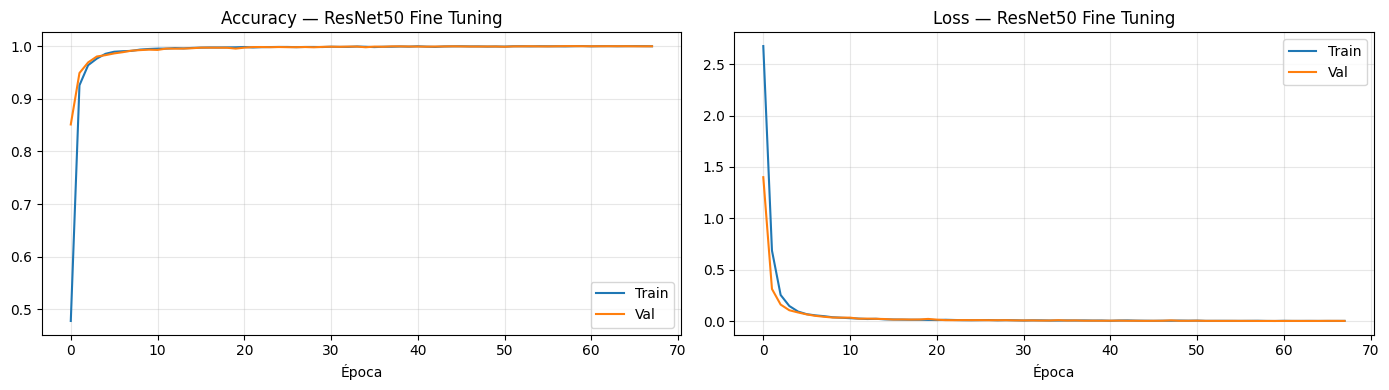

In [15]:
# Gráfica de entrenamiento
plot_history(history_r50, title="ResNet50 Fine Tuning")


  ResNet50 Fine Tuning — Test Accuracy: 99.96%
                          precision    recall  f1-score   support

  abraham_grampa_simpson       1.00      1.00      1.00       618
           agnes_skinner       1.00      1.00      1.00        33
  apu_nahasapeemapetilon       1.00      1.00      1.00       423
           barney_gumble       1.00      1.00      1.00        73
            bart_simpson       1.00      1.00      1.00       910
            carl_carlson       1.00      1.00      1.00        67
charles_montgomery_burns       1.00      1.00      1.00       812
            chief_wiggum       1.00      1.00      1.00       668
         cletus_spuckler       1.00      1.00      1.00        32
          comic_book_guy       1.00      1.00      1.00       319
               disco_stu       1.00      1.00      1.00         7
          edna_krabappel       1.00      1.00      1.00       315
                fat_tony       1.00      1.00      1.00        23
                     gil   

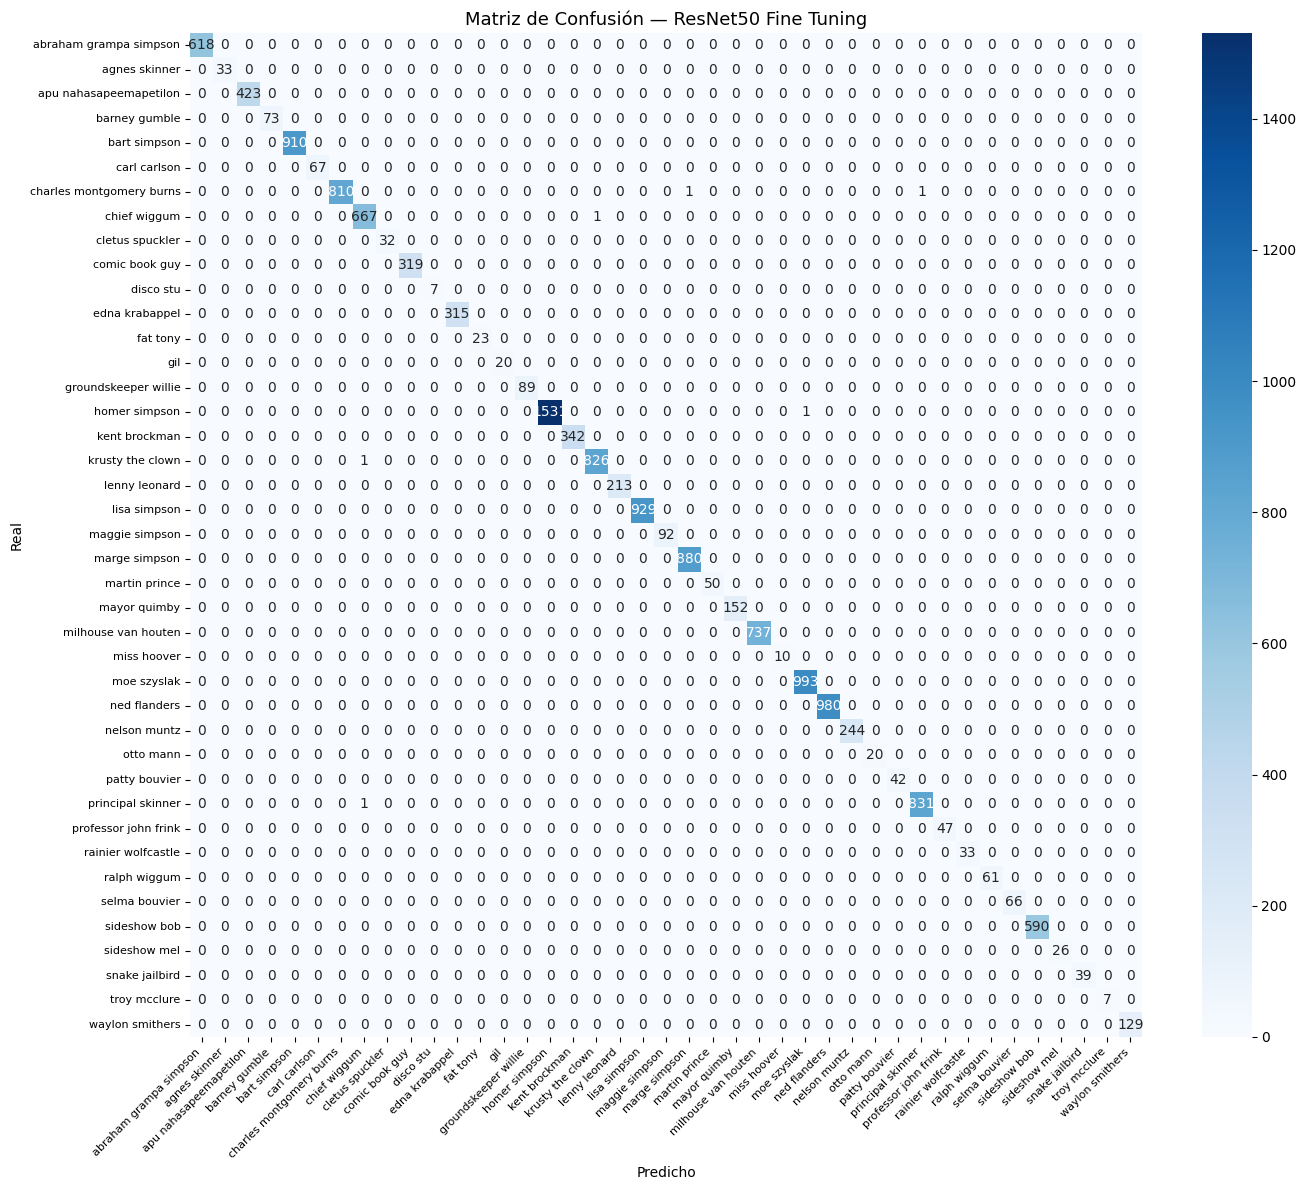

In [16]:
# Evaluamos el modelo calculando las métricas y la matriz de confusión usando la función full_evaluation
preds_r50, labels_r50 = full_evaluation(resnet_model, test_loader, device, class_names, title="ResNet50 Fine Tuning")

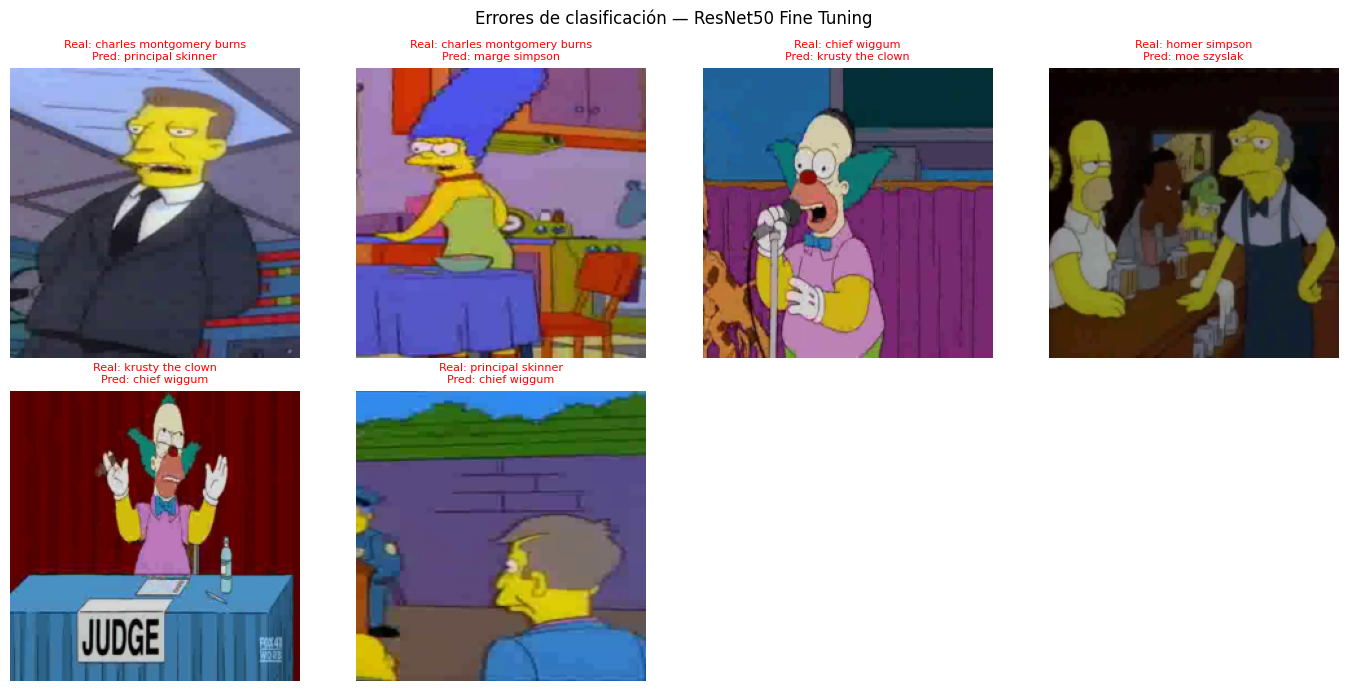

In [17]:
# Mostramos ejemplos de algunos errores cometidos por el modelo sobre el conjunto de test
show_errors(resnet_model, test_dataset, device, idx_to_class, n_errors=12, title="ResNet50 Fine Tuning")

## **Modelo 3:** VGG19 - Fine Tuning

In [18]:
# Cargar VGG19 preentrenado
vgg_model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

# Backbone descongelado para fine tuning
for param in vgg_model.parameters():
    param.requires_grad = True

# Reemplazamos la última capa del clasificador para clasificar en nuestras NUM_CLASES clases
in_features = vgg_model.classifier[6].in_features
vgg_model.classifier[6] = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASES)
)

# Usamos GPU
vgg_model = vgg_model.to(device)

# Mostramos el número de parámetros entrenables y no entrenables
trainable = sum(p.numel() for p in vgg_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in vgg_model.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Parámetros entrenables: 139,738,217 / 139,738,217 (100.0%)


In [19]:
# Función de pérdida
criterion_vgg = nn.CrossEntropyLoss()

# Definimos el optimizador del modelo
optimizer_vgg = optim.Adam(
    vgg_model.parameters(),
    lr=1e-5, weight_decay=1e-4
)

# Reduce Lr
scheduler_vgg = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_vgg, mode='min', factor=0.5, patience=5, min_lr=1e-8
)

# Entrenamos el modelo con 150 epochs
print("Entrenando Modelo 3: VGG19 Fine-Tuning...\n")
history_vgg = train_model(
    vgg_model, train_loader, val_loader,
    optimizer_vgg, criterion_vgg, scheduler_vgg,
    device, epochs=150, model_name='vgg19_ft.pth', patience=10
)

Entrenando Modelo 3: VGG19 Fine-Tuning...

Epoch   1/150 | Train Loss: 2.7757 Acc: 0.2742 | Val Loss: 1.0725 Acc: 0.7499 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.7499)
Epoch   2/150 | Train Loss: 0.7799 Acc: 0.7877 | Val Loss: 0.4697 Acc: 0.8784 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.8784)
Epoch   3/150 | Train Loss: 0.4039 Acc: 0.8926 | Val Loss: 0.2915 Acc: 0.9244 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9244)
Epoch   4/150 | Train Loss: 0.2671 Acc: 0.9291 | Val Loss: 0.2264 Acc: 0.9423 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9423)
Epoch   5/150 | Train Loss: 0.1879 Acc: 0.9481 | Val Loss: 0.1862 Acc: 0.9527 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9527)
Epoch   6/150 | Train Loss: 0.1544 Acc: 0.9590 | Val Loss: 0.1553 Acc: 0.9600 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9600)
Epoch   7/150 | Train Loss: 0.1202 Acc: 0.9678 | Val Loss: 0.1308 Acc: 0.9672 | LR: 1.00e-05
Mejor modelo guardado (val_acc=0.9672)
Epoch   8/150 | Train Loss: 0.108

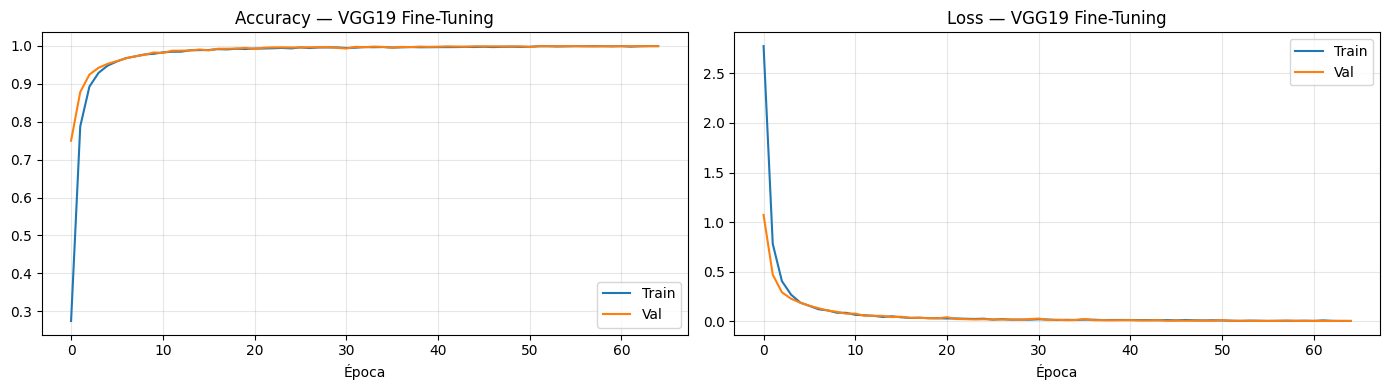

In [20]:
# Gráfica de entrenamiento
plot_history(history_vgg, title="VGG19 Fine-Tuning")


  VGG19 Fine-Tuning — Test Accuracy: 99.93%
                          precision    recall  f1-score   support

  abraham_grampa_simpson       1.00      1.00      1.00       618
           agnes_skinner       1.00      1.00      1.00        33
  apu_nahasapeemapetilon       1.00      1.00      1.00       423
           barney_gumble       1.00      1.00      1.00        73
            bart_simpson       1.00      1.00      1.00       910
            carl_carlson       1.00      1.00      1.00        67
charles_montgomery_burns       1.00      1.00      1.00       812
            chief_wiggum       1.00      1.00      1.00       668
         cletus_spuckler       1.00      1.00      1.00        32
          comic_book_guy       1.00      1.00      1.00       319
               disco_stu       1.00      1.00      1.00         7
          edna_krabappel       1.00      1.00      1.00       315
                fat_tony       1.00      1.00      1.00        23
                     gil      

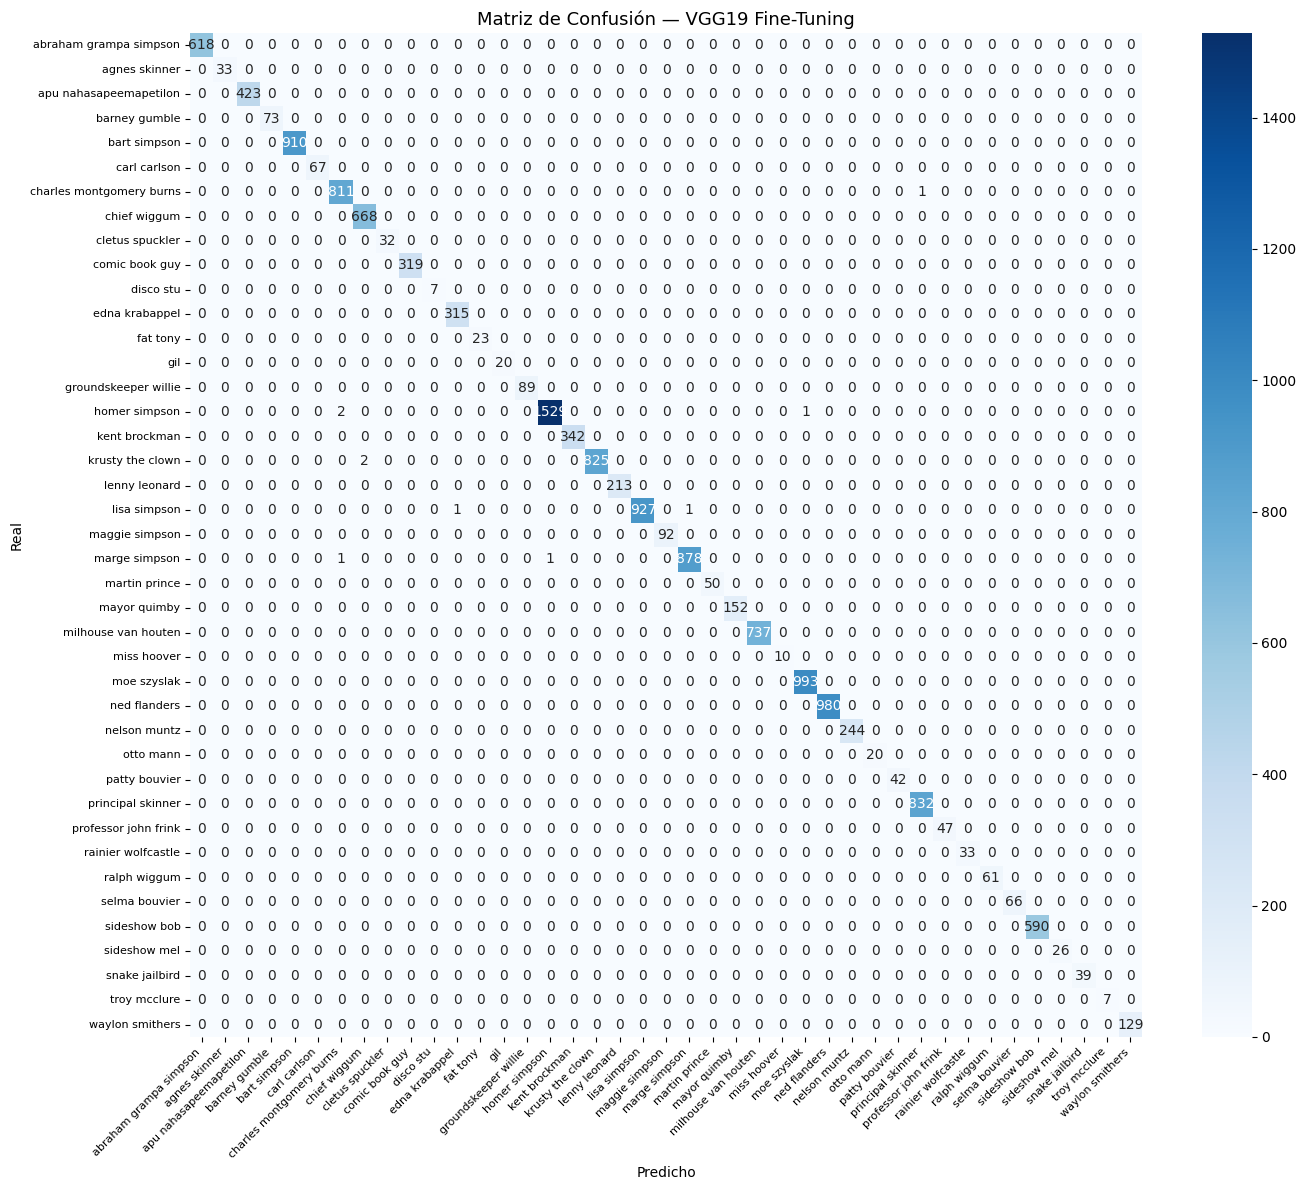

In [21]:
# Evaluamos el modelo calculando las métricas y la matriz de confusión usando la función full_evaluation
preds_vgg, labels_vgg = full_evaluation(vgg_model, test_loader, device, class_names, title="VGG19 Fine-Tuning")

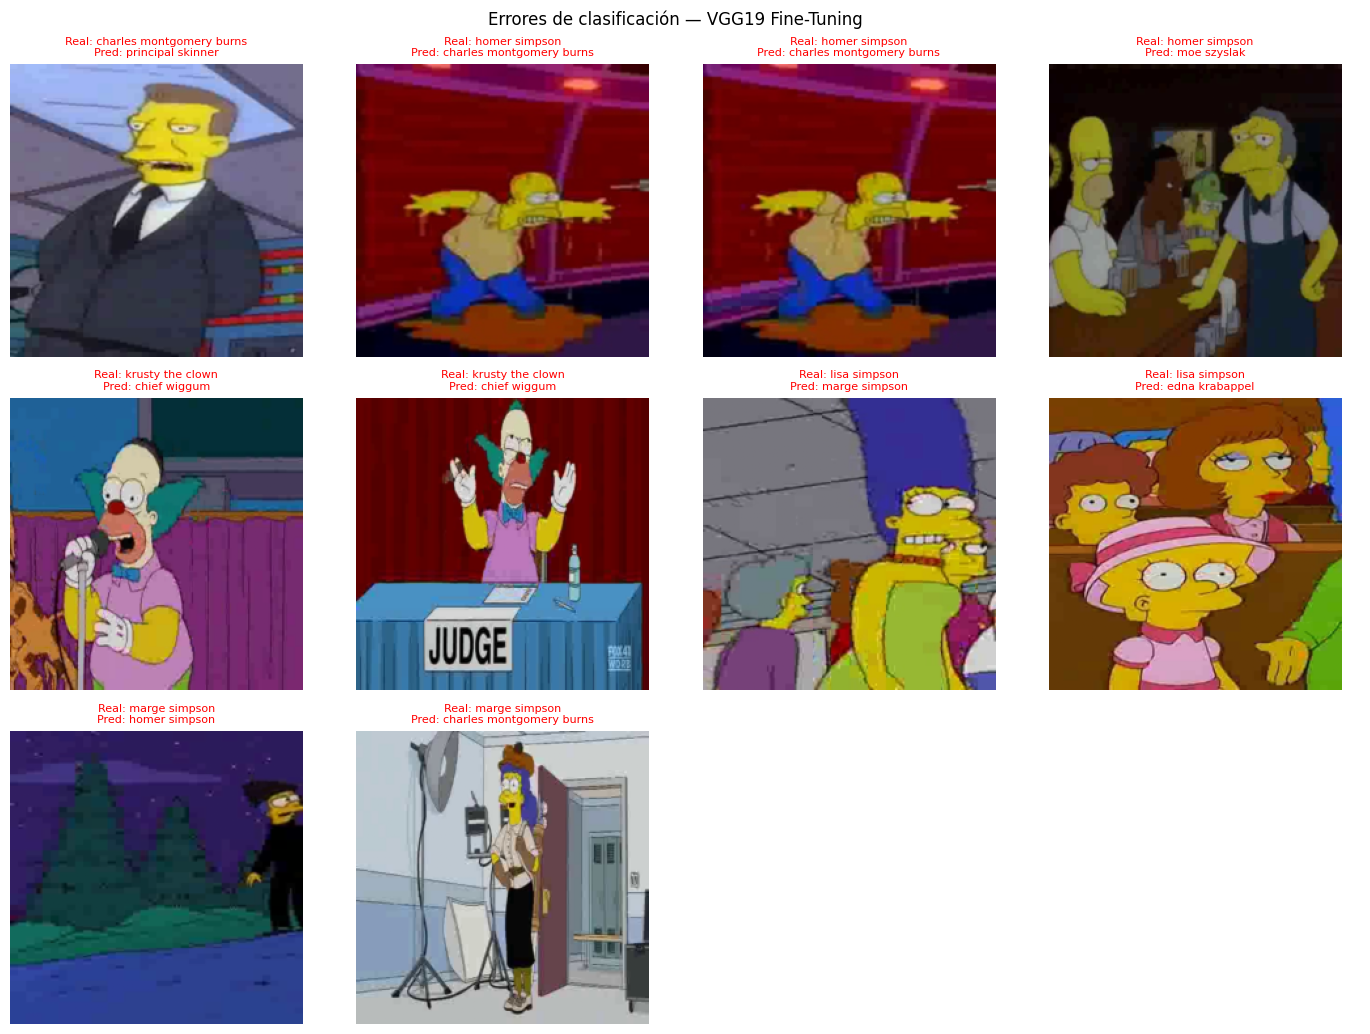

In [22]:
# Mostramos ejemplos de algunos errores cometidos por el modelo sobre el conjunto de test
show_errors(vgg_model, test_dataset, device, idx_to_class, n_errors=12, title="VGG19 Fine-Tuning")